In [2]:
import pandas as pd
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Mysql@27",
    database="retail_bi"
)

query = """
SELECT 
    order_date,
    sales,
    profit,
    region
FROM orders_clean;
"""

df = pd.read_sql(query, conn)
conn.close()

df.head()


C:\Users\Prashastini N\AppData\Local\Temp\ipykernel_17552\1738293127.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_date,sales,profit,region
0,2014-11-11,221.0,62.0,Central US
1,2014-02-05,3709.0,-288.0,Oceania
2,2014-10-17,5175.0,919.0,Oceania
3,2014-01-28,2892.0,-96.0,Western Europe
4,2014-11-05,2832.0,311.0,Western Africa


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_date  125 non-null    object 
 1   sales       125 non-null    float64
 2   profit      125 non-null    float64
 3   region      125 non-null    object 
dtypes: float64(2), object(2)
memory usage: 4.0+ KB


,sales,profit
count,125.000000,125.000000
mean,2362.288000,459.992000
std,1577.542545,701.704497
min,8.000000,-2211.000000
25%,1505.000000,28.000000
50%,2266.000000,313.000000
75%,3219.000000,763.000000
max,7958.000000,3979.000000


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='order_date'>

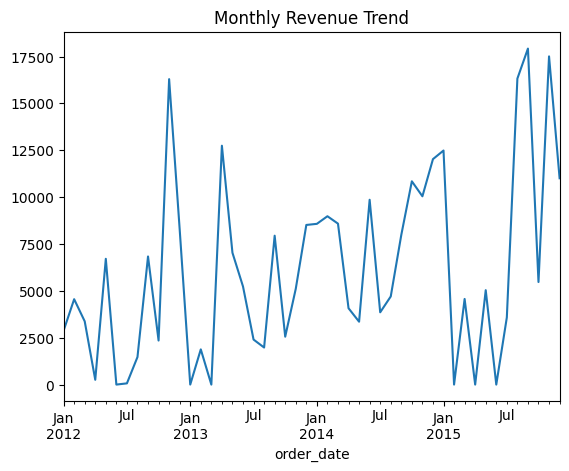

In [4]:
df['order_date'] = pd.to_datetime(df['order_date'])
monthly_revenue = df.resample('M', on='order_date')['sales'].sum()
monthly_revenue.plot(title='Monthly Revenue Trend')
